In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

# Carregar modelo e dados
with open('../data/processed/xgb_regressor.pkl', 'rb') as f:
    xgb = pickle.load(f)

df = pd.read_csv('../data/processed/insurance_features.csv')

X = df.drop(columns=['charges', 'log_charges'])

print("Modelo carregado!")
print("Shape:", X.shape)

Modelo carregado!
Shape: (99989, 15)


In [2]:
# Calcular SHAP — usar amostra de 5000 para ser mais rápido
sample = X.sample(5000, random_state=42)

explainer   = shap.Explainer(xgb)
shap_values = explainer(sample)

print("SHAP values calculados ✅")
print("Shape dos SHAP values:", shap_values.values.shape)

SHAP values calculados ✅
Shape dos SHAP values: (5000, 15)


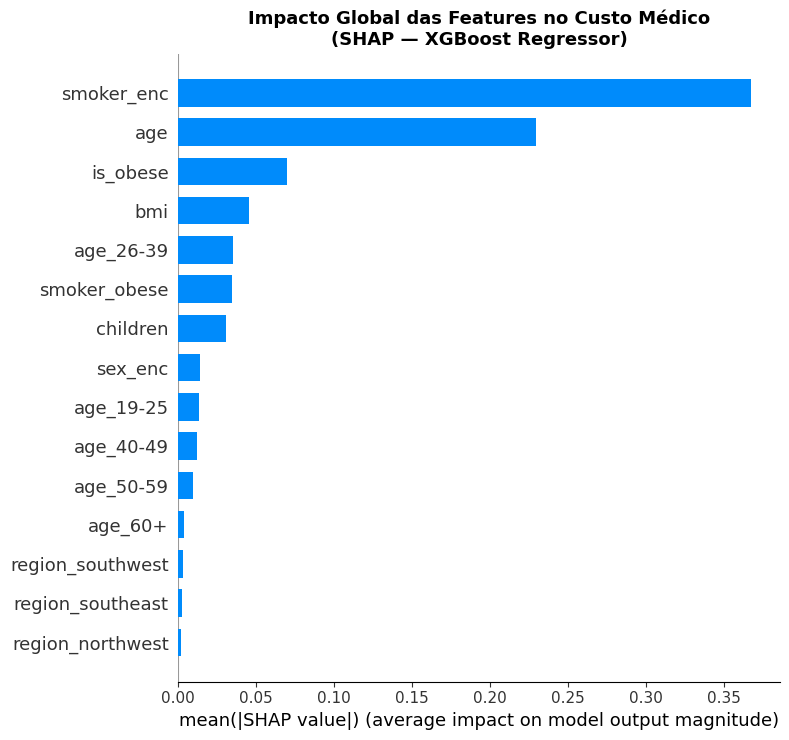

In [3]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample, plot_type="bar",
                  show=False)
plt.title('Impacto Global das Features no Custo Médico\n(SHAP — XGBoost Regressor)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

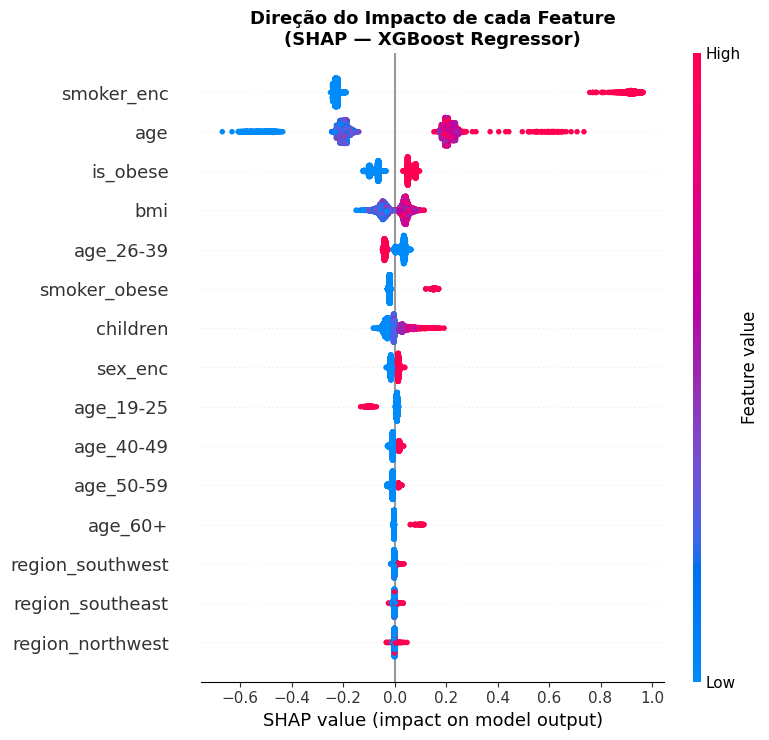

In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, sample, show=False)
plt.title('Direção do Impacto de cada Feature\n(SHAP — XGBoost Regressor)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


  Perfil: Fumante obeso (alto custo)
  Custo previsto: $42,885.27


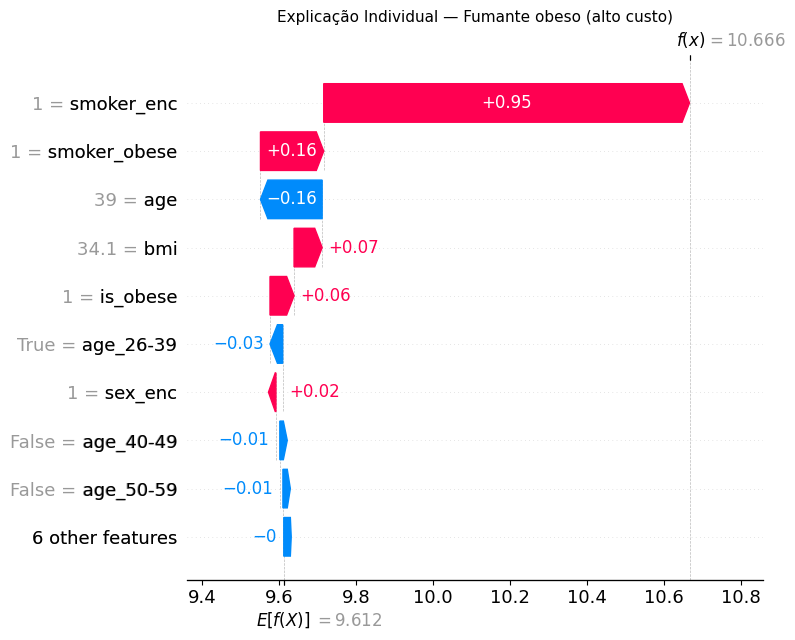


  Perfil: Não fumante jovem (baixo custo)
  Custo previsto: $6,407.24


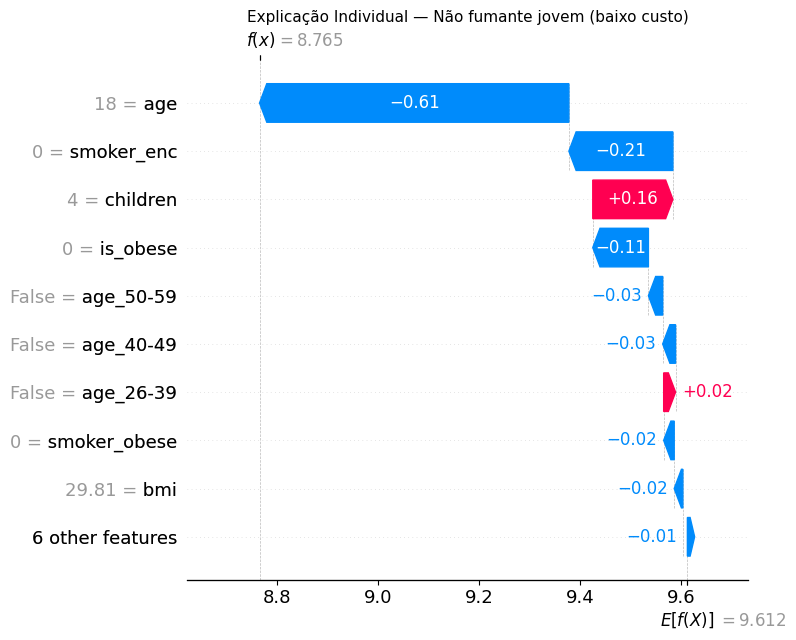


  Perfil: Não fumante idoso (médio custo)
  Custo previsto: $26,115.12


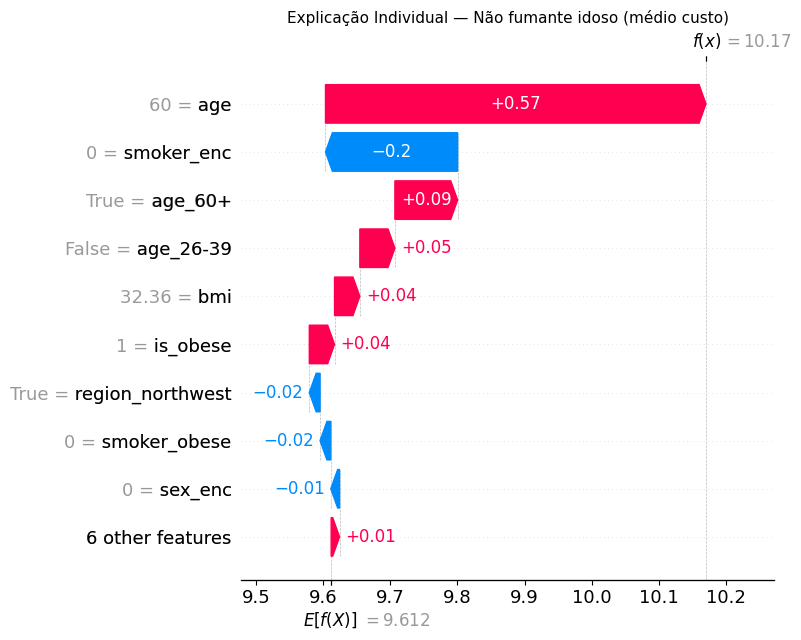

In [5]:
# Pegar 3 perfis diferentes para explicar
perfis = {
    'Fumante obeso (alto custo)':
        X[(df['smoker_enc']==1) & (df['is_obese']==1)].iloc[0],
    'Não fumante jovem (baixo custo)':
        X[(df['smoker_enc']==0) & (df['age']<=25)].iloc[0],
    'Não fumante idoso (médio custo)':
        X[(df['smoker_enc']==0) & (df['age']>=60)].iloc[0],
}

for nome, perfil in perfis.items():
    shap_ind = explainer(pd.DataFrame([perfil]))
    custo_previsto = np.exp(xgb.predict(pd.DataFrame([perfil]))[0])
    print(f"\n{'='*50}")
    print(f"  Perfil: {nome}")
    print(f"  Custo previsto: ${custo_previsto:,.2f}")
    print(f"{'='*50}")
    shap.waterfall_plot(shap_ind[0], show=False)
    plt.title(f'Explicação Individual — {nome}', fontsize=11)
    plt.tight_layout()
    plt.show()

In [6]:
# Importância média por feature
shap_df = pd.DataFrame(shap_values.values, columns=sample.columns)
importancia = shap_df.abs().mean().sort_values(ascending=False)

print("=" * 50)
print("  RANKING DE IMPORTÂNCIA — SHAP")
print("=" * 50)
for feat, val in importancia.items():
    print(f"  {feat:<25} → {val:.4f}")

# Insight principal
top1 = importancia.index[0]
top2 = importancia.index[1]
ratio = importancia.iloc[0] / importancia.iloc[1]
print(f"\n💡 '{top1}' é {ratio:.1f}x mais importante que '{top2}'")

  RANKING DE IMPORTÂNCIA — SHAP
  smoker_enc                → 0.3679
  age                       → 0.2298
  is_obese                  → 0.0699
  bmi                       → 0.0456
  age_26-39                 → 0.0351
  smoker_obese              → 0.0342
  children                  → 0.0308
  sex_enc                   → 0.0139
  age_19-25                 → 0.0135
  age_40-49                 → 0.0118
  age_50-59                 → 0.0097
  age_60+                   → 0.0038
  region_southwest          → 0.0028
  region_southeast          → 0.0025
  region_northwest          → 0.0015

💡 'smoker_enc' é 1.6x mais importante que 'age'
